# Classificador de Flores: Rosas vs. Tulipas

## 1. Configuração Inicial e Importações

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
import zipfile
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import load_img, img_to_array

## 2. Download e Preparação do Dataset

In [ ]:
# URL do dataset do seu repositório (link direto para download)
url = "https://github.com/mramgti/RNA/raw/main/datasets/classifier/flowers.zip"
zip_filename = "flowers.zip"
extracted_folder_name = "flowers"

print(f"Baixando o dataset do GitHub de {url}...")
response = requests.get(url)

# Verificação de segurança: garante que o download deu certo antes de salvar
if response.status_code == 200:
    with open(zip_filename, "wb") as f:
        f.write(response.content)
    print("Download concluído!")

    # Extrai o conteúdo preservando a estrutura original
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(".")

    print(f"Dataset extraído com sucesso para o diretório: {extracted_folder_name}")

    # Define a variável 'path' para o diretório base do dataset extraído
    path = os.path.join(".", extracted_folder_name, "")
    print(f"Caminho do dataset configurado: {path}")

    # Clean up the zip file after extraction
    os.remove(zip_filename)
    print(f"Arquivo zip temporário '{zip_filename}' removido.")
else:
    print(f"Erro ao baixar o dataset. Código de status: {response.status_code}")

Baixando o dataset do GitHub de https://github.com/mramgti/RNA/raw/main/datasets/classifier/flowers.zip...
Download concluído!
Dataset extraído com sucesso para o diretório: flowers
Caminho do dataset configurado: ./flowers/
Arquivo zip temporário 'flowers.zip' removido.


## 3. Configuração dos Geradores de Imagens

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 1. CORREÇÃO DE RESOLUÇÃO: Alterado de 128 para 256 para dar mais nitidez à rede
IM_SIZE = (256, 256)

# 2. CORREÇÃO DE PRÉ-PROCESSAMENTO: Trocamos o rescale tradicional pela função do Google
gerador_treinamento = ImageDataGenerator(
    preprocessing_function = preprocess_input, # Alinha o padrão de pixels para [-1, 1]
    rotation_range = 50,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range = 0.1,
    zoom_range = 0.1,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

# Aplicamos a mesma correção de pixels para os dados de validação/teste
gerador_teste = ImageDataGenerator(preprocessing_function = preprocess_input)

print("Carregando as imagens com a nova resolução de 256x256...")

base_treinamento = gerador_treinamento.flow_from_directory(
    path + 'train_set', # Certifique-se de que a variável 'path' termina com '/' (ex: 'dados/')
    target_size = IM_SIZE,
    batch_size = 32,
    class_mode = 'binary'
)

base_teste = gerador_teste.flow_from_directory(
    path + 'test_set',
    target_size = IM_SIZE,
    batch_size = 32,
    class_mode = 'binary'
)

Carregando as imagens com a nova resolução de 256x256...
Found 1428 images belonging to 2 classes.
Found 340 images belonging to 2 classes.


## 4. Criação da Estrutura da Rede Neural (CNN)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

# 1. Carrega a base - CORRIGIDO: Mudado de 128 para 256 aqui também!
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# 2. Ativamos o Fine-Tuning (Descongelamento Parcial)
base_model.trainable = True

# MobileNetV2 tem 154 camadas. Vamos congelar até a 110
fine_tune_at = 110
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Montagem da Rede
cnn_model = Sequential([
    Input(shape=(256, 256, 3)),         # Sincronizado perfeitamente aqui!
    base_model,
    GlobalAveragePooling2D(),
    Dense(units=96, activation='relu'), # Seu ajuste para 96 neurônios mantido
    Dropout(0.4),
    Dense(units=1, activation='sigmoid')
])

# 4. COMPILAÇÃO CRÍTICA: Taxa de aprendizado MUITO baixa (1e-5) para o fine-tuning
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔥 Modo Fine-Tuning Ativado! Rede configurada para 256x256 e pronta para rodar.")

/tmp/ipykernel_64976/25431356.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(256, 256, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
🔥 Modo Fine-Tuning Ativado! Rede configurada para 256x256 e pronta para rodar.


## 5. Treinamento da Rede Neural

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Evita o overfitting salvando os melhores pesos atingidos
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

# Reduz o passo do otimizador se a acurácia estagnar
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

print("Iniciando o treinamento otimizado da CNN...")
history = cnn_model.fit(
    base_treinamento,
    epochs = 40,
    validation_data = base_teste,
    callbacks=[early_stop, lr_reducer] # Removidos steps_per_epoch/validation_steps
)
print("Treinamento concluído!")

Iniciando o treinamento otimizado da CNN...
Epoch 1/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.5203 - loss: 0.7640 - val_accuracy: 0.6059 - val_loss: 0.6529 - learning_rate: 1.0000e-05
Epoch 2/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6155 - loss: 0.6662 - val_accuracy: 0.6176 - val_loss: 0.6412 - learning_rate: 1.0000e-05
Epoch 3/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6422 - loss: 0.6417 - val_accuracy: 0.6235 - val_loss: 0.6248 - learning_rate: 1.0000e-05
Epoch 4/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6912 - loss: 0.5910 - val_accuracy: 0.6559 - val_loss: 0.5933 - learning_rate: 1.0000e-05
Epoch 5/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7108 - loss: 0.5639 - val_accuracy: 0.7176 - val_loss: 0.5553 - learning_rate: 1.0000e-05
Epoch 6/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.7423 - loss: 0.5132 - val_accuracy: 0.7088 - val_loss: 0.5521 - learning_rate: 1.0000e-05
Epoch 7/40
45/45 ━━━━━━━━━━━━━━━

## 6. Salvando e Carregando o Modelo Treinado

In [ ]:
# Definindo o caminho usando o novo padrão recomendado (.keras)
model_save_path = 'modelo_rosas_tulipas.h5'

# Salva a arquitetura, pesos e estado do otimizador de forma nativa
cnn_model.save(model_save_path)

print("="*40)
print(f"🎉 Modelo salvo com sucesso em:\n -> {model_save_path}")
print("="*40)

🎉 Modelo salvo com sucesso em:
 -> modelo_rosas_tulipas.h5


In [ ]:
from tensorflow.keras.models import load_model

# Definindo o caminho (alinhado com o formato .keras que usamos para salvar)
model_load_path = 'modelo_rosas_tulipas.h5'

# Se você optou por manter o formato antigo, basta descomentar a linha abaixo:
# model_load_path = 'flores_tulipas_model.h5'

# Carrega o modelo de forma segura
loaded_model = load_model(model_load_path)

print("="*40)
print(f"📂 Modelo '{model_load_path}' carregado com sucesso para predição!")
print("="*40)

📂 Modelo 'modelo_rosas_tulipas.h5' carregado com sucesso para predição!


7 - Dupla visualização do Carregamento
Menor que 0.5 = Rosas
Maior que 0.5 = Tulipas

In [ ]:
# 1. Carregando a imagem para o professor ver
imagem_visual = load_img(image_path_for_prediction)
plt.imshow(imagem_visual)
plt.axis('off')
plt.show()

NameError: name 'image_path_for_prediction' is not defined

In [ ]:
# 2. Preparando a imagem para o modelo (Seguindo o padrão do professor)
imagem_teste = load_img(image_path_for_prediction, target_size=(256, 256))
imagem_teste = img_to_array(imagem_teste)

# Usando o padrão MobileNetV2 (Fundamental para a precisão!)
imagem_teste = preprocess_input(imagem_teste)
imagem_teste = np.expand_dims(imagem_teste, axis=0)

# CORREÇÃO: Usar o cnn_model (classificador) em vez do modelo_aprendizado_visual (reconstrutor)
prediction = cnn_model.predict(imagem_teste)

# Resultado
# Como o modelo é binário, prediction[0][0] agora será um único número entre 0 e 1
valor = prediction[0][0]
print(f"Probabilidade (Score): {valor:.4f}")

if valor < 0.5:
    print('Classe: Rose (Rosa)')
else:
    print('Classe: Tulip (Tulipa)')

NameError: name 'image_path_for_prediction' is not defined

## 7. Realizando Predições com o Modelo Carregado

👉 Imagem selecionada em pasta alternativa: download (3).jpg


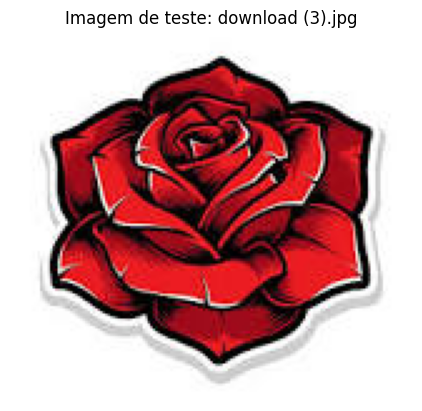

Valor bruto da predição: 0.01865275
Resultado: A imagem foi classificada como -> ROSE


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Corrigindo o caminho para o ambiente do Colab
path = '/content/flowers'

# 1. Configuração dos caminhos
NOME_DO_MODELO = 'modelo_rosas_tulipas.h5'
pasta_testes_rosas = os.path.join(path, 'test_set', 'rose')

# Carrega o modelo
# Nota: Certifique-se que o arquivo .h5 está na pasta /content/
cnn_model = load_model(NOME_DO_MODELO)

# Busca automaticamente a primeira imagem disponível na pasta
if os.path.exists(pasta_testes_rosas) and os.listdir(pasta_testes_rosas):
    arquivos = [f for f in os.listdir(pasta_testes_rosas) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if arquivos:
        NOME_DA_IMAGEM = os.path.join(pasta_testes_rosas, arquivos[0])
        print(f"👉 Imagem selecionada automaticamente: {arquivos[0]}")
    else:
        raise FileNotFoundError("Nenhuma imagem (.jpg, .png) foi encontrada dentro da pasta 'rose'.")
else:
    # Verifica se a pasta existe sem o 'test_set' caso a estrutura seja diferente
    alternativa = os.path.join(path, 'rose')
    if os.path.exists(alternativa):
        pasta_testes_rosas = alternativa
        arquivos = [f for f in os.listdir(pasta_testes_rosas) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        NOME_DA_IMAGEM = os.path.join(pasta_testes_rosas, arquivos[0])
        print(f"👉 Imagem selecionada em pasta alternativa: {arquivos[0]}")
    else:
        raise FileNotFoundError(f"A pasta {pasta_testes_rosas} não existe. Verifique se o dataset foi extraído no Colab.")

# Dicionário de classes
class_labels = {0: 'rose', 1: 'tulip'}

# 2. Carregar e exibir a imagem original
imagem_original = load_img(NOME_DA_IMAGEM)
plt.imshow(imagem_original)
plt.title(f"Imagem de teste: {os.path.basename(NOME_DA_IMAGEM)}")
plt.axis('off')
plt.show()

# 3. Pré-processar a imagem (MobileNetV2 espera 256x256)
imagem_teste = load_img(NOME_DA_IMAGEM, target_size=(256, 256))
imagem_teste = img_to_array(imagem_teste)
imagem_teste = preprocess_input(imagem_teste)
imagem_teste = np.expand_dims(imagem_teste, axis=0)

# 4. Realizar a predição
prediction_raw = cnn_model.predict(imagem_teste, verbose=0)

# 5. Interpretar o resultado
prediction_value = prediction_raw[0][0]
if prediction_value < 0.5:
    classe_prevista_nome = class_labels[0] # 'rose'
else:
    classe_prevista_nome = class_labels[1] # 'tulip'

print("="*40)
print(f"Valor bruto da predição: {prediction_value:.8f}")
print(f"Resultado: A imagem foi classificada como -> {classe_prevista_nome.upper()}")
print("="*40)


## 8. Avaliação de Acurácia no Conjunto de Teste Completo

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

acertos = 0
total = 0
rosas_cont = 0
tulipas_cont = 0

# Verifica onde as pastas de flores realmente estão
if os.path.exists(os.path.join(path, 'test_set')):
    test_folder = os.path.join(path, 'test_set')
else:
    test_folder = path

print(f"Buscando imagens em: {test_folder}")

for classe_real_folder in ['rose', 'tulip']:
    pasta_classe = os.path.join(test_folder, classe_real_folder)

    if not os.path.exists(pasta_classe):
        print(f"⚠️ Aviso: Pasta {pasta_classe} não encontrada, ignorando.")
        continue

    arquivos_na_pasta = [f for f in os.listdir(pasta_classe) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Processando {len(arquivos_na_pasta)} imagens da classe: {classe_real_folder}...")

    for arquivo in arquivos_na_pasta:
        caminho = os.path.join(pasta_classe, arquivo)

        # Processamento padrão 256x256
        img = load_img(caminho, target_size=(256, 256))
        img = img_to_array(img)
        img = preprocess_input(img)
        img = np.expand_dims(img, axis=0)

        # Predição
        pred = cnn_model.predict(img, verbose=0)
        classe_prevista_idx = 0 if pred[0][0] < 0.5 else 1
        classe_prevista_nome = class_labels[classe_prevista_idx]

        if classe_prevista_nome == classe_real_folder:
            acertos += 1

        if classe_prevista_nome == 'rose':
            rosas_cont += 1
        else:
            tulipas_cont += 1
        total += 1

# Relatório Final
porcentagem_final = (acertos / total) * 100 if total > 0 else 0

print("\n" + "="*50)
print(f"🎯 ACURÁCIA FINAL NO TESTE: {porcentagem_final:.2f}%")
print(f"📊 Total de imagens avaliadas: {total}")
print(f"   -> Rosas previstas pelo modelo: {rosas_cont}")
print(f"   -> Tulipas previstas pelo modelo: {tulipas_cont}")
print("="*50)

Buscando imagens em: /content/flowers
Processando 5 imagens da classe: rose...
Processando 4 imagens da classe: tulip...

🎯 ACURÁCIA FINAL NO TESTE: 77.78%
📊 Total de imagens avaliadas: 9
   -> Rosas previstas pelo modelo: 3
   -> Tulipas previstas pelo modelo: 6


Gerando dados para a matriz de confusão...


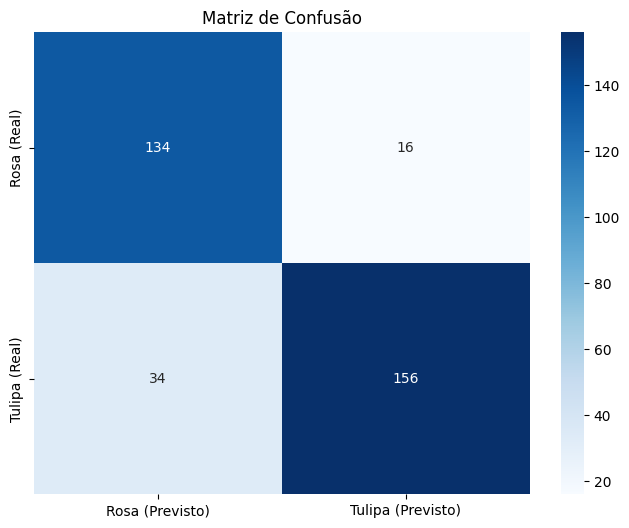

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

print("Gerando dados para a matriz de confusão...")
y_true = []
y_pred = []

# Percorre o conjunto de teste para coletar rótulos reais e predições
for classe_nome in ['rose', 'tulip']:
    pasta = os.path.join(path, 'test_set', classe_nome)
    label_real = 0 if classe_nome == 'rose' else 1

    for arquivo in os.listdir(pasta):
        if arquivo.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(pasta, arquivo)
            img = load_img(img_path, target_size=(256, 256))
            img = img_to_array(img)
            img = preprocess_input(img)
            img = np.expand_dims(img, axis=0)

            pred = cnn_model.predict(img, verbose=0)
            label_previsto = 0 if pred[0][0] < 0.5 else 1

            y_true.append(label_real)
            y_pred.append(label_previsto)

# Agora que temos os dados, criamos a matriz
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rosa (Previsto)', 'Tulipa (Previsto)'],
            yticklabels=['Rosa (Real)', 'Tulipa (Real)'])
plt.title('Matriz de Confusão')
plt.show()

134 Rosas foram classificadas corretamente como Rosas.
156 Tulipas foram classificadas corretamente como Tulipas.
Houve 16 erros onde Rosas foram confundidas com Tulipas.
Houve 34 erros onde Tulipas foram confundidas com Rosas.
Isso mostra que o modelo é ligeiramente mais preciso ao identificar Rosas

Instruções para Avaliação:
Certifique-se de que o arquivo modeloh5 esteja no mesmo diretório deste notebook.

O modelo espera imagens no formato 256x256.

Certifique-se de aplicar o preprocess_input da MobileNetV2 nas imagens de teste antes de passá-las para a função model.predict().